# FNQS with disorder
---

A Foundation NQS trained over a family of **disorder realizations** learns a single variational state
$\psi(\sigma; \mathbf{h})$ valid across the full ensemble.  After training it generalises to
**unseen** realizations via `vs.get_state(new_params)` — no retraining required.

The key difference from the uniform-field case (see **[Tutorial 1](1.%20FNQS%20training%20basics.ipynb)**)
is that the Hamiltonian parameter is now a *vector* of length $L$, one random field per site:

$$
\hat H(\mathbf{h}) = -\sum_{i=1}^L \sigma^z_i\sigma^z_{i+1} - \sum_{i=1}^L h_i\,\sigma^x_i,
\qquad h_i \overset{\text{iid}}{\sim} \mathcal{U}(0, h_\text{max})
$$

This tutorial covers:

1. Encoding site-level disorder in a `ParameterSpace` of dimension $L$
2. Training with $N_\text{train}$ disorder replicas simultaneously
3. Evaluating energy accuracy on held-out realizations

In [40]:
import os
os.environ["NETKET_EXPERIMENTAL_SHARDING"] = "1"
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")

import time
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

import netket as nk
import netket_foundation as nkf
from netket_foundation._src.model.vit import ViTFNQS

## System: disordered 1D Ising chain
---

$L = 10$ spins with periodic boundary conditions. Each realization draws independent random fields
$h_i \sim \mathcal{U}(0, h_\text{max})$ with $h_\text{max} = 1.5$.
We generate $N_\text{train} = 8$ training realizations and $N_\text{test} = 4$ held-out test realizations.

In [ ]:
L     = 10
h_max = 2.0

hi    = nk.hilbert.Spin(0.5, L)
graph = nk.graph.Chain(L, pbc=True)

rng = np.random.default_rng(42)

n_train = 16
n_test  = 256

params_train = rng.uniform(-h_max//2, h_max//2, size=(n_train, L))  # (16, L)
params_test  = rng.uniform(-h_max//2, h_max//2, size=(n_test,  L))  # (256, L) — never seen during training

print(f"Train realizations : {n_train}")
print(f"Test  realizations : {n_test}")
print(f"Example h[0]: {params_train[0].round(2)}")

Train realizations : 16
Test  realizations : 256
Example h[0]: [1.55 0.88 1.72 1.39 0.19 1.95 1.52 1.57 0.26 0.9 ]


## FNQS building blocks
---

With site-level disorder the Hamiltonian parameter is a *vector* of size $L$, so `ParameterSpace(N=L)`.
Inside `ParametrizedOperator`, the driver calls `create_operator(params)` inside `jax.vmap` — one
call per replica — so `params[i]` are JAX-traced scalars multiplying per-site Pauli operators.

In [42]:
ps = nkf.ParameterSpace(N=L, min=0, max=h_max)

def create_operator(params):
    ha_ZZ = sum(
        nkf.operator.sigmaz(hi, i) @ nkf.operator.sigmaz(hi, (i + 1) % L)
        for i in range(L)
    )
    ha_X = sum(params[i] * nkf.operator.sigmax(hi, i) for i in range(L))
    return -ha_ZZ - ha_X

ha_p = nkf.operator.ParametrizedOperator(hi, ps, create_operator)

Mz  = sum(nkf.operator.sigmaz(hi, i) for i in range(L)) * (1.0 / L)
Mz2 = Mz @ Mz
Mz2_sp = Mz2.to_sparse()

print(f"ParameterSpace dim : {ps.size}  (one field per site)")

ParameterSpace dim : 10  (one field per site)


## Model and variational state
---

Two flags differ from the uniform case: `disorder=True` activates site-dependent coupling embeddings
and `transl_invariant=False` disables translation-invariant pooling, since the disorder breaks the
lattice symmetry.  Each of the $N_\text{train}$ replicas is assigned one disorder realization.

In [43]:
import optax

ma = ViTFNQS(
    num_layers=2,
    d_model=12,
    heads=4,
    L_eff=L // 2,
    n_coups=ps.size,
    b=2,
    complex=False,
    disorder=True,
    transl_invariant=False,
    two_dimensional=False,
)

sa = nk.sampler.MetropolisLocal(hi, n_chains=256)
vs = nkf.FoundationalQuantumState(sa, ma, ps, n_samples=1024, n_replicas=n_train, seed=1)

vs.parameter_array = jnp.array(params_train)

print(f"Parameters : {vs.n_parameters}")
print(f"Replicas   : {vs.n_replicas},  samples : {vs.n_samples}")

Parameters : 3542
Replicas   : 16,  samples : 1024


## Training
---

Same `VMC_NG` driver as Tutorial 1. Each optimisation step processes all $N_\text{train}$ replicas
simultaneously through a single natural-gradient update.

In [44]:
diag_shift = optax.exponential_decay(1e-2, transition_steps=32, decay_rate=0.5)
optimizer  = optax.sgd(0.01)
gs = nkf.VMC_NG(ha_p, optimizer, variational_state=vs, diag_shift=diag_shift)

t0 = time.perf_counter()
gs.run(512, show_progress=True)
print(f"Training done in {time.perf_counter() - t0:.0f} s")

online_statistics: chain_length=4, exponential moving average window: 50, decay=0.920


  0%|          | 0/512 [00:00<?, ?it/s]

Training done in 80 s


## Generalisation to unseen disorder
---

After training, `vs.get_state(params)` returns an `MCState` for *any* disorder vector — including the
test realizations never seen during optimisation.  We compare the FNQS energies against exact
diagonalization for both sets.

In [45]:
def evaluate_energies(params_list):
    fnqs_E, ed_E, fnqs_Mz2, ed_Mz2 = [], [], [], []
    for params in params_list:
        params_jnp = jnp.array(params)

        # FNQS: extract MCState and sample
        mc = vs.get_state(params_jnp)
        mc.n_samples = 4096
        for _ in range(8):
            mc.sample()
        op = create_operator(params_jnp)
        fnqs_E.append(float(mc.expect(op).mean.real))
        fnqs_Mz2.append(float(mc.expect(Mz2).mean.real))

        # Exact diagonalization
        e0, psi0 = nk.exact.lanczos_ed(op, k=1, compute_eigenvectors=True)
        psi0 = psi0.reshape(-1)
        ed_E.append(float(e0[0]))
        ed_Mz2.append(float(np.real(psi0.conj() @ (Mz2_sp @ psi0))))

    return (np.array(fnqs_E), np.array(ed_E),
            np.array(fnqs_Mz2), np.array(ed_Mz2))


fnqs_train, ed_train, fnqs_Mz2_train, ed_Mz2_train = evaluate_energies(params_train)
fnqs_test,  ed_test,  fnqs_Mz2_test,  ed_Mz2_test  = evaluate_energies(params_test)

print(f"Train  |ΔE|/L    = {np.abs(fnqs_train - ed_train).mean() / L:.4f}")
print(f"Test   |ΔE|/L    = {np.abs(fnqs_test  - ed_test ).mean() / L:.4f}")
print(f"Train  |ΔMz²|    = {np.abs(fnqs_Mz2_train - ed_Mz2_train).mean():.4f}")
print(f"Test   |ΔMz²|    = {np.abs(fnqs_Mz2_test  - ed_Mz2_test ).mean():.4f}")

Train  |ΔE|/L    = 0.0007
Test   |ΔE|/L    = 0.0090
Train  |ΔMz²|    = 0.0090
Test   |ΔMz²|    = 0.0314


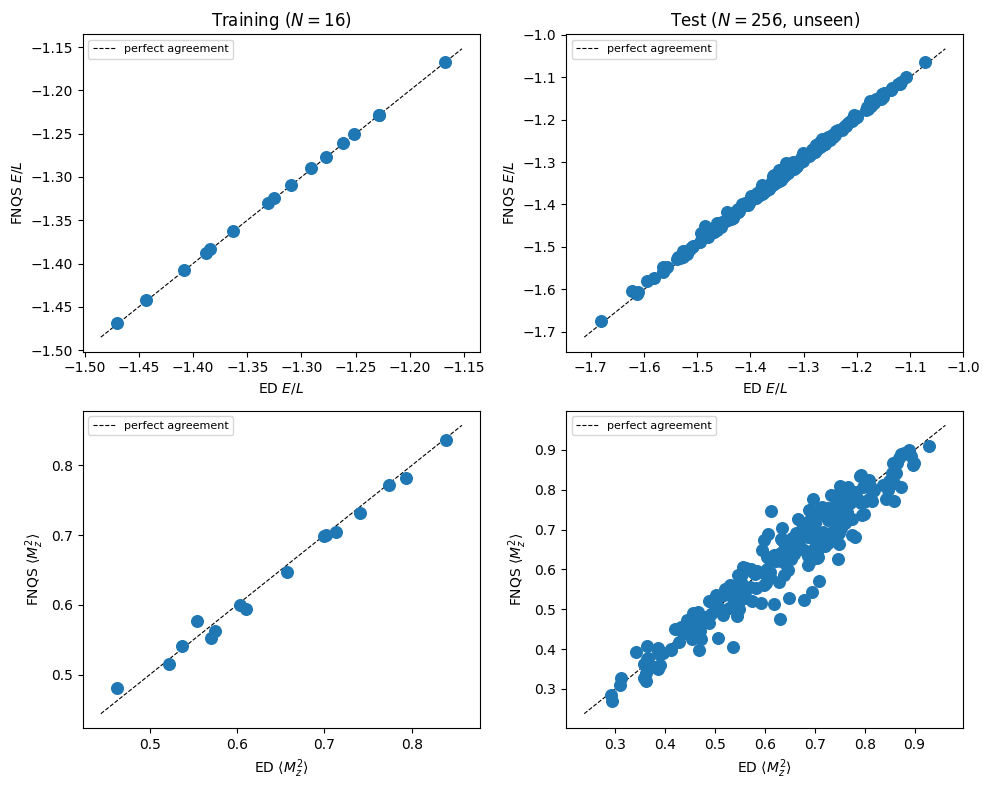

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

datasets = [
    (fnqs_train, ed_train,      fnqs_Mz2_train, ed_Mz2_train, f"Training ($N={n_train}$)"),
    (fnqs_test,  ed_test,       fnqs_Mz2_test,  ed_Mz2_test,  f"Test ($N={n_test}$, unseen)"),
]

for col, (fnqs_E, ed_E, fnqs_mz2, ed_mz2, title) in enumerate(datasets):
    for row, (fnqs_val, ed_val, ylabel) in enumerate([
        (fnqs_E / L, ed_E / L, "FNQS $E/L$"),
        (fnqs_mz2,   ed_mz2,   r"FNQS $\langle M_z^2 \rangle$"),
    ]):
        ax = axes[row, col]
        lo = min(ed_val.min(), fnqs_val.min())
        hi_ = max(ed_val.max(), fnqs_val.max())
        margin = 0.05 * (hi_ - lo)
        lim = [lo - margin, hi_ + margin]
        ax.plot(lim, lim, "k--", lw=0.8, label="perfect agreement")
        ax.scatter(ed_val, fnqs_val, s=70, zorder=5)
        if row == 0:
            ax.set_title(title)
        ax.set_xlabel("ED" + (" $E/L$" if row == 0 else r" $\langle M_z^2 \rangle$"))
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()